In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sys import path
path.append('../wavelet/')
path.append('../signals/')

import wavelet_funcs as wf
import signals as sg

In [7]:
from scipy.signal import periodogram

## No Noise

Mean dt: 0.5
Min dt: 0.11279338361885038
Max dt: 0.9939373439849013


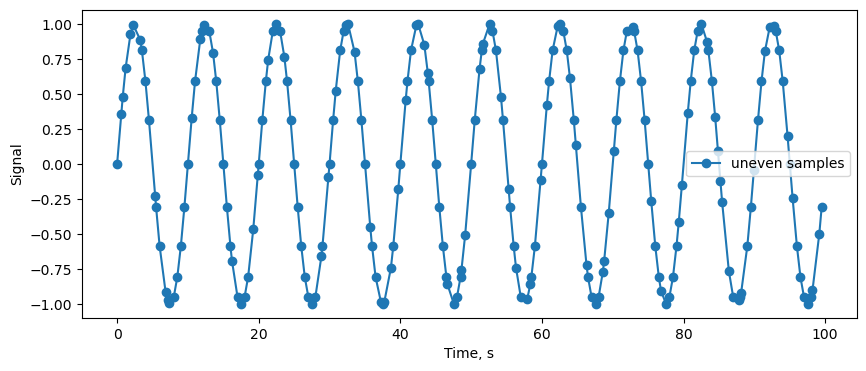

In [12]:

# Parameters
duration = 100          # seconds
mean_dt = 0.5           # seconds
min_dt = 0.1
max_dt = 1.0
freq = 0.1              # Hz
shift_fraction = 0.4    # fraction of time points to perturb
rng = np.random.default_rng(0)

# 1) Start with evenly sampled time points
t = np.arange(0, duration, mean_dt)

# 2) Shift a fraction of internal points back/forth
t_uneven = t.copy()

n = len(t)
n_shift = int(shift_fraction * n)

# Avoid shifting first/last points
idx = rng.choice(np.arange(1, n - 1), size=n_shift, replace=False)

for i in idx:
    left_limit = t_uneven[i - 1] + min_dt
    right_limit = t_uneven[i + 1] - min_dt

    # Also enforce max step to neighbors
    left_limit = max(left_limit, t_uneven[i + 1] - max_dt)
    right_limit = min(right_limit, t_uneven[i - 1] + max_dt)

    if left_limit < right_limit:
        t_uneven[i] = rng.uniform(left_limit, right_limit)

# 3) Generate sine at unevenly sampled time points
y = np.sin(2 * np.pi * freq * t_uneven)
y_even = np.sin(2 * np.pi * freq * t)

# 4) Check time steps
dt = np.diff(t_uneven)

print("Mean dt:", dt.mean())
print("Min dt:", dt.min())
print("Max dt:", dt.max())

# 5) Plot
plt.figure(figsize=(10, 4))
plt.plot(t_uneven, y, "o-", label="uneven samples")
plt.xlabel("Time, s")
plt.ylabel("Signal")
plt.legend()
plt.show()

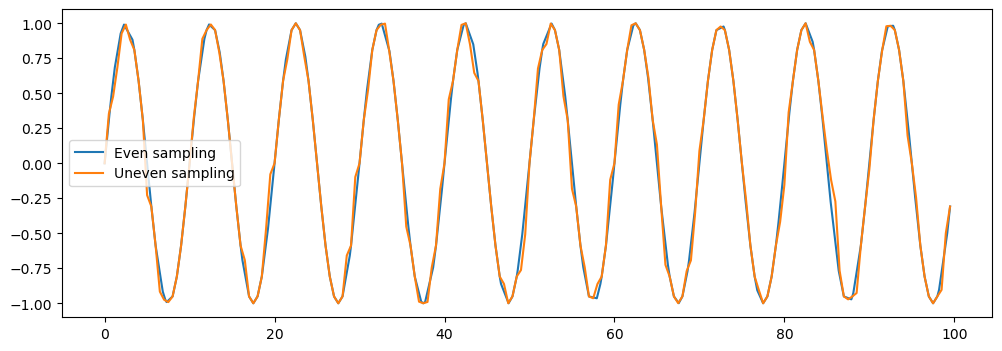

In [18]:
f, ax = plt.subplots(figsize=(12,4))
ax.plot(t_uneven, y, label='Even sampling')
ax.plot(t, y, label='Uneven sampling')
plt.legend()

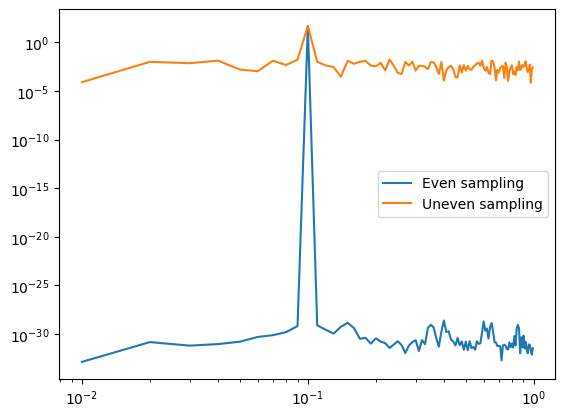

In [17]:
frq, pxx = periodogram(y_even, fs=2)
plt.loglog(frq[1:-1], pxx[1:-1], label='Even sampling')

frq, pxx = periodogram(y, fs=2)
plt.loglog(frq[1:-1], pxx[1:-1], label='Uneven sampling')

plt.legend()

## With noise

Mean dt: 0.5
Min dt: 0.11279338361885038
Max dt: 0.9939373439849013


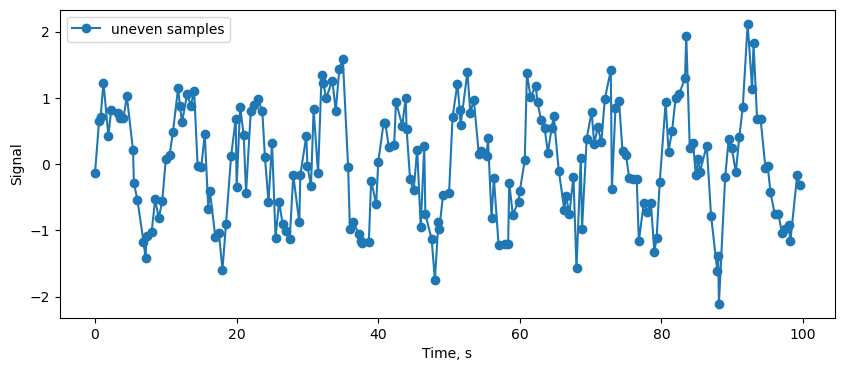

In [22]:

# Parameters
duration = 100          # seconds
mean_dt = 0.5           # seconds
min_dt = 0.1
max_dt = 1.0
freq = 0.1              # Hz
shift_fraction = 0.4    # fraction of time points to perturb
rng = np.random.default_rng(0)

# 1) Start with evenly sampled time points
t = np.arange(0, duration, mean_dt)

# 2) Shift a fraction of internal points back/forth
t_uneven = t.copy()

n = len(t)
n_shift = int(shift_fraction * n)

# Avoid shifting first/last points
idx = rng.choice(np.arange(1, n - 1), size=n_shift, replace=False)

for i in idx:
    left_limit = t_uneven[i - 1] + min_dt
    right_limit = t_uneven[i + 1] - min_dt

    # Also enforce max step to neighbors
    left_limit = max(left_limit, t_uneven[i + 1] - max_dt)
    right_limit = min(right_limit, t_uneven[i - 1] + max_dt)

    if left_limit < right_limit:
        t_uneven[i] = rng.uniform(left_limit, right_limit)

# 3) Generate sine at unevenly sampled time points
noise = np.random.randn(t.size)/2
y = np.sin(2 * np.pi * freq * t_uneven) + noise
y_even = np.sin(2 * np.pi * freq * t) + noise

# 4) Check time steps
dt = np.diff(t_uneven)

print("Mean dt:", dt.mean())
print("Min dt:", dt.min())
print("Max dt:", dt.max())

# 5) Plot
plt.figure(figsize=(10, 4))
plt.plot(t_uneven, y, "o-", label="uneven samples")
plt.xlabel("Time, s")
plt.ylabel("Signal")
plt.legend()
plt.show()

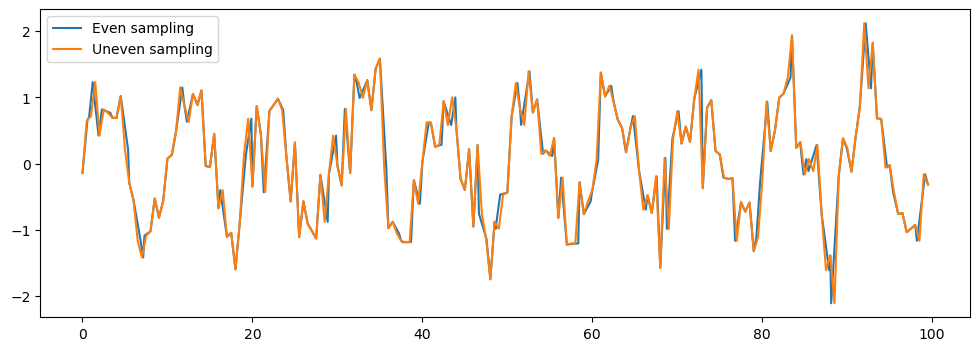

In [23]:
f, ax = plt.subplots(figsize=(12,4))
ax.plot(t_uneven, y, label='Even sampling')
ax.plot(t, y, label='Uneven sampling')
plt.legend()

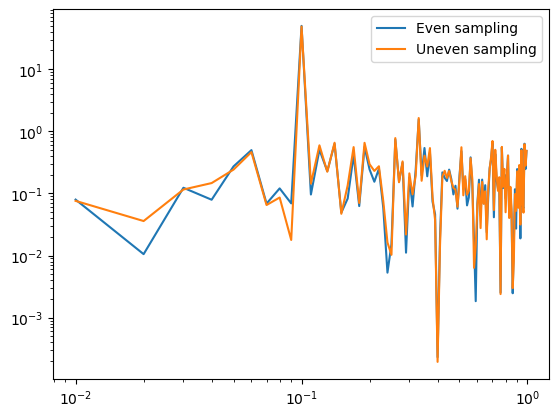

In [24]:
frq, pxx = periodogram(y_even, fs=2)
plt.loglog(frq[1:-1], pxx[1:-1], label='Even sampling')

frq, pxx = periodogram(y, fs=2)
plt.loglog(frq[1:-1], pxx[1:-1], label='Uneven sampling')

plt.legend()